# Figure 2: Cyclin CDK Validation story

**Goal:** Validate deconvolution results with known cell cycle regulation story.

**Background:**
Cyclins *CLB2* and *CLN1/2* frequently appear as examples in which the chromatin is clearly cycling with cell cycle regulation. We can show that this is a known story that can be recapitulated and will validate the deconvolution methodology.

**Procedure:**
1. Incorporate the binding sites for transcription factors: ChIP-exo and FIMO/YEASTRACT (prioritize ChIP-exo).
2. Identify cyclins that tell the best story and what their chromatin signatures are.
    - Starting with *CLB2*, *CLN1/2*
3. Potentially we should be able to show, using a heatmap the entire cyclin-CDK story space and how the chromatin is changing/changes in relation to gene expression.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Among the cyclins, it appears entropy of the +2 nucleosome may be a clear signal

In [3]:
# If this dataset is too small, we can look at the FIMO hits for the genes we are interested
# We can crosscheck the set of CCTFs from Kelliher with the FIMO/YEASTRACT dataset. 
# Check if the CCTFs from Kelliher is complete, or if there is another list of more TFs
# somewhere

# Cyclins and CDKs, what do their chromatin and gene expression look like?

## three G1 cyclins:
- **CLN1** - Promoter binding in S-phase, +1 and +2 nucleosome binding dynamics
- **CLN2** - Some binding in end of G1, +1 and +2 binding dynamics in S-phase
- CLN3 - Sparse nucleosome reads, not a great example

## Two S-phase cyclins:
- CLB5 - Misaligned to +2, potential, but unclear +1 binding dynamics
- CLB6 - No reads in deconvolution (or very sparse prior to smoothing)

## And four mitotic cyclins:
- CLB1 - Subtle
- **CLB2** - Promoter and nucleosome activity, sparse prior to smoothing
- CLB3 - Sparsity during S phase, replication copy # effects?
- CLB4 - Sparsity during S phase, replication copy # effects?





In [5]:
from src.geneset import cyclin_genes
cyclin_genes()

['CLN1', 'CLN2', 'CLN3', 'CLB5', 'CLB6', 'CLB1', 'CLB2', 'CLB3', 'CLB4']

CLB3
Loading MNase reads for YDL155W/CLB3...Loading chromosome reads: 4
Done.
Applying chromatin copy number correction
Loading MNase reads for YDL155W/CLB3...Loading chromosome reads: 4
Done.
Applying chromatin copy number correction
Deconvolving combined model with gamma=0.006
Deconvolving bin size: 11x11
of G shape: (31, 2093)
Deconvolving with gamma=0.006
0/2093 - 00:00:00.084
500/2093 - 00:00:35.037
1000/2093 - 00:01:06.515
1500/2093 - 00:01:38.164
2000/2093 - 00:02:08.730
Deconvolved in : 00:02:15.319
The fitting norm is 13.46, the smoothing norm is: 4.25
There are 118 MacIsaac TFs
There are 49 cell cycle transcription factors (CCTFs) profiled by Kelliher, 2018
There are 340 transcription factors profiled using ChIP-exo by Rossi, 2021
There are 17 CCTFS in the Rossi dataset.
There are 22 CCTFS in the MacIsaac dataset.
CLB4
Loading MNase reads for YLR210W/CLB4...Loading chromosome reads: 12
Done.
Applying chromatin copy number correction
Loading MNase reads for YLR210W/CLB4...Load

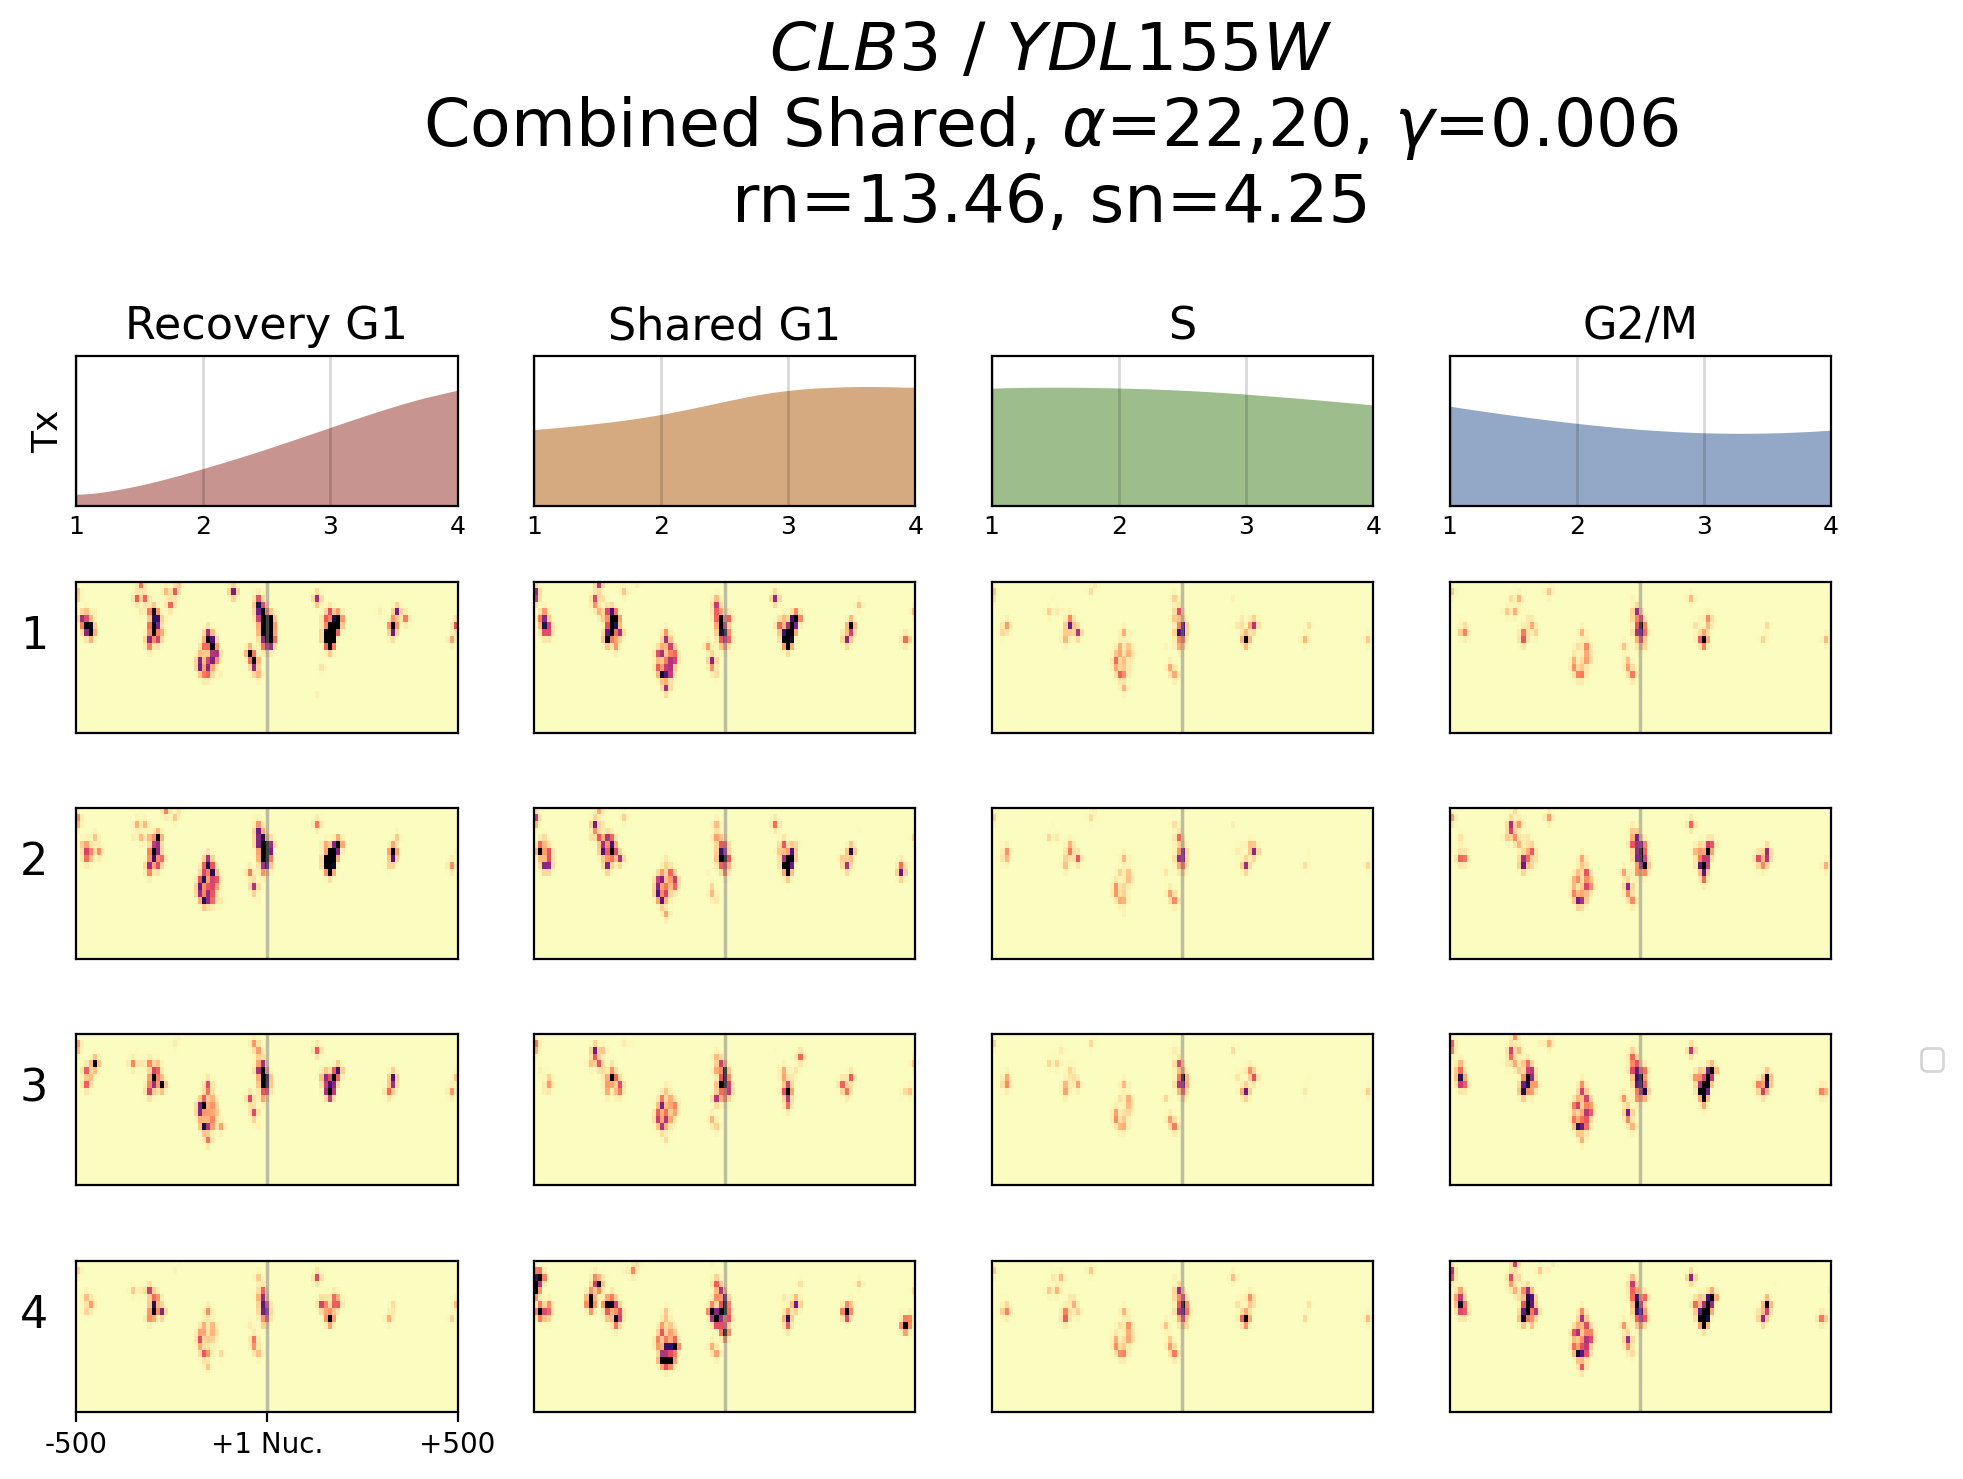

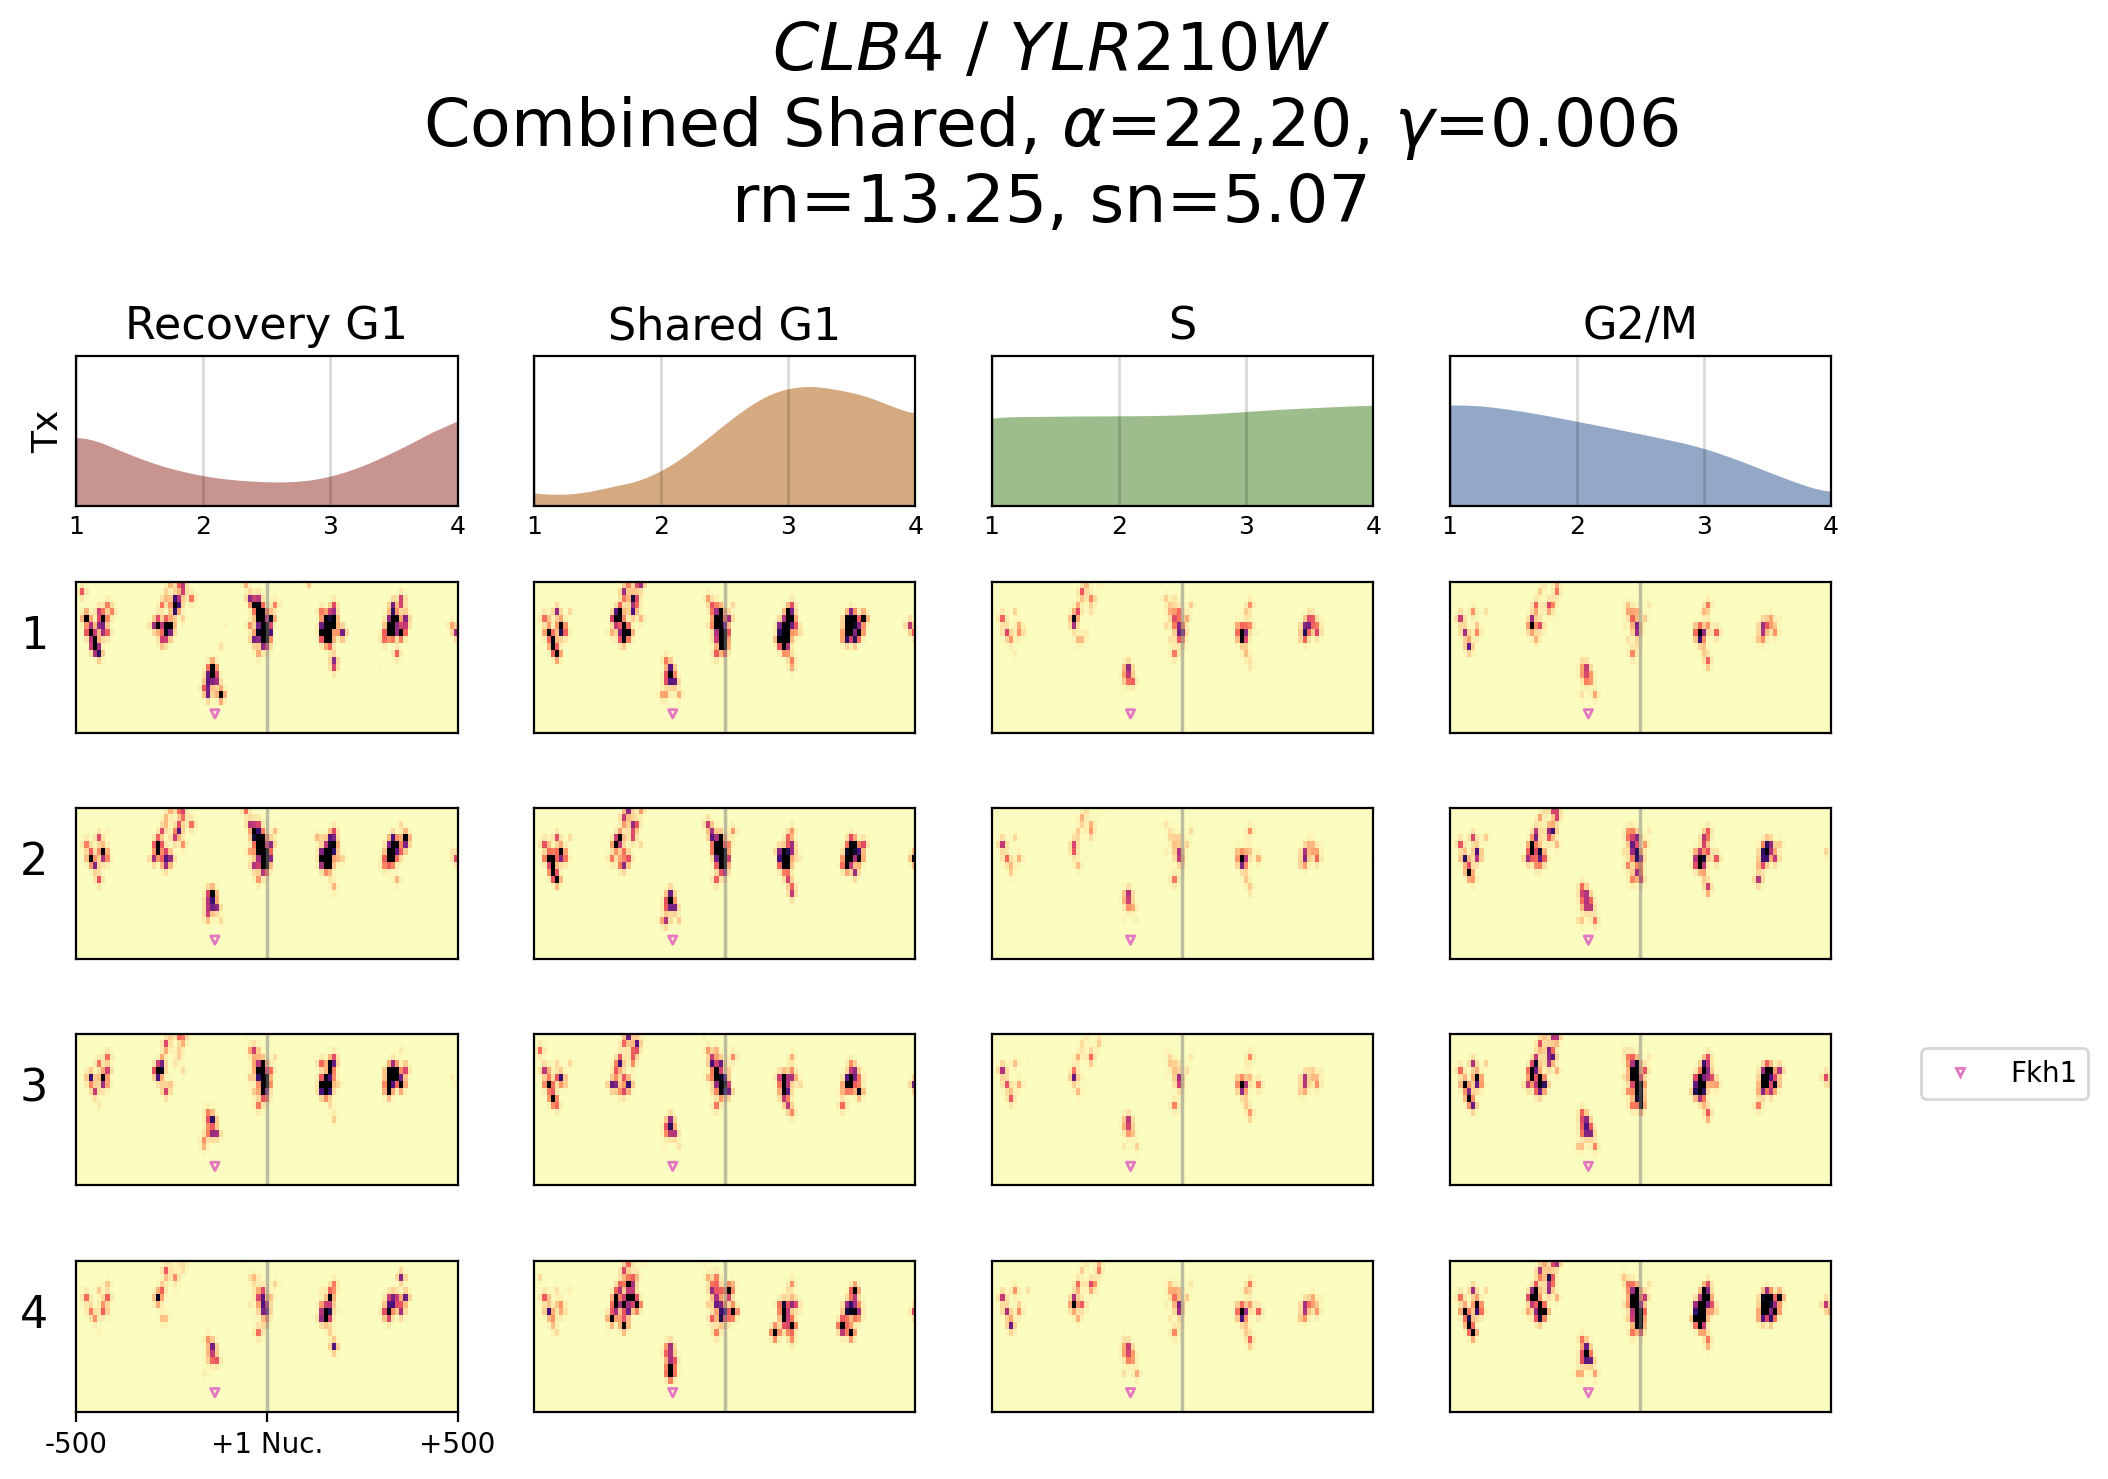

In [6]:
from src.config import load_configs_by_config_type, \
    load_combined_gene_expression_by_config_type
from src.model import Model
from src.combined_chromatin_model import CombinedChromatinModel
from src.geneset import cyclin_genes

for gene_name in cyclin_genes():
    
    print(gene_name)
    
    config1, config2 = load_configs_by_config_type('shared')
    combined_ge_config = load_combined_gene_expression_by_config_type('shared')

    combined_ge_model = Model(combined_ge_config, gene_name)
    combined_ge_model.deconvolve_find_optimal_gamma()
    combined_model = CombinedChromatinModel(config1, config2)

    combined_model.load_combined_mnase_gene(gene_name)
    combined_model.gamma = 0.0066
    combined_model.deconvolve()
    
    # -------------------------
    
    from src.figure_configs import save_figure_for_paper

    fig = combined_model.create_deconvolution_plots_abbreviated_flipped(
        should_smooth_data=True, vmax=10, ge_model=combined_ge_model)
    save_figure_for_paper(f'output/figures/Cyclins_Story/{gene_name}_w_motifs.png')

    del combined_model
    del combined_ge_model
